<a href="https://colab.research.google.com/github/shin-noda/deep-learning-with-python/blob/main/Chapter9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Residual connections

In [ ]:
import keras
from keras import layers

inputs = keras.Input(shape=(32, 32, 3))

x = layers.Conv2D(32, 3, activation="relu")(inputs)

# Sets aside the residual
residual = x

# This is the alyer around which we create a residau connect:
# it increases the number of output filters from 32 to 64.
# We use padding="same" to avoid downsampling due to padding.
x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)

# The residual only had 32 filters, so we use a 1 x 1 Conv2D to project it to the correct shape.
residual = layers.Conv2D(64, 1)(residual)

# Now the block output and the residual have the same shape and can be added.
x = layers.add([x, residual])

In [ ]:
inputs = keras.Input(shape=(32, 32, 3))

x = layers.Conv2D(32, 3, activation="relu")(inputs)

# Sets aside the residual
residual = x

# This is the block of two layers around which we create a residual connection:
# it includes a 2 x 2 max pooling layer.
# We use padding="same" in both the convolution layer and the max pooling
# layer to avoid downsampling due to padding.
x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
x = layers.MaxPooling2D(2, padding="same")(x)

# We use strides=2 in the residual projection to match the downsampling
# created by the max pooling layer.
residual = layers.Conv2D(64, 1, strides=2)(residual)

# Now the block output and the residual have the same shape and can be added.
x = layers.add([x, residual])

In [ ]:
inputs = keras.Input(shape=(32, 32, 3))
x = layers.Rescaling(1.0 / 255)(inputs)

# Utility function to apply a convolutional block with a residual
# connection, with an option to add max pooling
def residual_block(x, filters, pooling=False):
    residual = x
    x = layers.Conv2D(filters, 3, activation="relu", padding="same")(x)
    x = layers.Conv2D(filters, 3, activation="relu", padding="same")(x)

    if pooling:
        x = layers.MaxPooling2D(2, padding="same")(x)

        # If we use max pooling, we add a strided convolution to
        # project the residual to the expected shape
        residual = layers.Conv2D(filters, 1, strides=2)(residual)

    elif filters != residual.shape[-1]:
        # If we don't use max pooling, we only project the residual if
        # the number of channels has changed
        residual = layers.Conv2D(filters, 1)(residual)

    x = layers.add([x, residual])

    return x

# First block
x = residual_block(x, filters=32, pooling=True)

# Second block. Note the increasing filter count in each block.
x = residual_block(x, filters=64, pooling=True)

# The last block doesn't need a max pooling layer, since we will apply
# global average pooling right after it.
x = residual_block(x, filters=128, pooling=False)

x = layers.GlobalAveragePooling2D()(x)

outputs = layers.Dense(1, activation="sigmoid")(x)

model = keras.Model(inputs=inputs, outputs=outputs)

In [ ]:
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_10      │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_4         │ (None, 32, 32, 3) │          0 │ input_layer_10[0… │
│ (Rescaling)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_48 (Conv2D)  │ (None, 32, 32,    │        896 │ rescaling_4[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_49 (Conv2D)  │ (None, 32, 32,    │      9,248 │ conv2d_48[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_17    │ (None, 16, 16,    │          0 │ conv2d_49[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_50 (Conv2D)  │ (None, 16, 16,    │        128 │ rescaling_4[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_22 (Add)        │ (None, 16, 16,    │          0 │ max_pooling2d_17… │
│                     │ 32)               │            │ conv2d_50[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_51 (Conv2D)  │ (None, 16, 16,    │     18,496 │ add_22[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_52 (Conv2D)  │ (None, 16, 16,    │     36,928 │ conv2d_51[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_18    │ (None, 8, 8, 64)  │          0 │ conv2d_52[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_53 (Conv2D)  │ (None, 8, 8, 64)  │      2,112 │ add_22[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_23 (Add)        │ (None, 8, 8, 64)  │          0 │ max_pooling2d_18… │
│                     │                   │            │ conv2d_53[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_54 (Conv2D)  │ (None, 8, 8, 128) │     73,856 │ add_23[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_55 (Conv2D)  │ (None, 8, 8, 128) │    147,584 │ conv2d_54[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_56 (Conv2D)  │ (None, 8, 8, 128) │      8,320 │ add_23[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_24 (Add)        │ (None, 8, 8, 128) │          0 │ conv2d_55[0][0],  │
│                     │                   │            │ conv2d_56[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ add_24[0][0]      │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 1)         │        129 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴─────────────────

 Total params: 297,697 (1.14 MB)

 Trainable params: 297,697 (1.14 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Batch normalization

In [ ]:
# # Note the lack of activation here.
# x = layers.Conv2D(32, 3, use_bias=False)(x)
# x = layers.BatchNormalization()(x)

# # We place the activation after the BatchNormalization layer.
# x = layers.Activation("relu")(x)

In [ ]:
# Depthwise separable convolutions

In [ ]:
# Putting it together: A mini Xception-like model

In [ ]:
file_path = '/content/drive/MyDrive/Colab Notebooks/Deep Learning with Python/data'

In [ ]:
import os
import shutil
import pathlib

# Path to the directory containing the original dataset
original_dir = pathlib.Path(file_path)

# Directory where we will store our smaller dataset
new_base_dir = pathlib.Path(file_path + "/dogs_vs_cats_small")

In [ ]:
import keras

inputs = keras.Input(shape=(180, 180, 3))

# Don't forget input rescaling
x = layers.Rescaling(1.0 / 255)(inputs)

# the assumption that underlies seprabable convolution, "Feature
# channels are largetly independent," does not hold for RGB images.
# Red, green, and blue colour channels are actually highly correlated in natural images.
# As such, the first layer in our model is a regulr 'Conv2D' layer.
# We'll start using`SeparableConv2D` afterward.
x = layers.Conv2D(filters=32, kernel_size=5, use_bias=False)(x)

# We apply a series of convolutional blocks with increasing feature depth.
# Each block consists of two batch-normalized depthwise separable convolution layers
# and a max pooling layer, with a residual connections around the entire block.
for size in [32, 64, 128, 256, 512]:
    residual = x

    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.SeparableConv2D(size, 3, padding="same", use_bias=False)(x)

    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.SeparableConv2D(size, 3, padding="same", use_bias=False)(x)

    x = layers.MaxPooling2D(3, strides=2, padding="same")(x)

    residual = layers.Conv2D(
        size, 1, strides=2, padding="same", use_bias=False
    )(residual)

    x = layers.add([x, residual])

# In the origianl model, we used a Flatten layer before the Dense layer.
# Here, we go with a GlobalAveragePooling2D layer.
x = layers.GlobalAveragePooling2D()(x)

# Like in the original model, we add a dropout layer for regularization
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs=inputs, outputs=outputs)

In [ ]:
model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"],
)

In [ ]:
from keras.utils import image_dataset_from_directory

batch_size = 64
image_size = (180, 180)
train_dataset = image_dataset_from_directory(
    new_base_dir / "train", image_size=image_size, batch_size=batch_size
)

validation_dataset = image_dataset_from_directory(
    new_base_dir / "validation", image_size=image_size, batch_size=batch_size
)

test_dataset = image_dataset_from_directory(
    new_base_dir / "test", image_size=image_size, batch_size=batch_size
)

Found 1999 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Found 1998 files belonging to 2 classes.


In [ ]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="convnet_from_scratch.keras",
        save_best_only=True,
        monitor="val_loss",
    )
]

history = model.fit(
    train_dataset,
    epochs=100,
    validation_data=validation_dataset,
    callbacks=callbacks,
)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 270ms/step - accuracy: 1.0000 - loss: 0.0025 - val_accuracy: 0.7810 - val_loss: 0.9996
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 265ms/step - accuracy: 0.9990 - loss: 0.0029 - val_accuracy: 0.7850 - val_loss: 1.1332
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 261ms/step - accuracy: 0.9750 - loss: 0.0834 - val_accuracy: 0.7550 - val_loss: 1.5353
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 284ms/step - accuracy: 0.9825 - loss: 0.0536 - val_accuracy: 0.7530 - val_loss: 1.1558
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 262ms/step - accuracy: 0.9940 - loss: 0.0165 - val_accuracy: 0.7710 - val_loss: 1.0894
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 257ms/step - accuracy: 0.9920 - loss: 0.0158 - val_accuracy: 0.7810 - val_loss: 1.1859
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 275ms/step - accuracy: 0.9990 - loss: 0.0058 - val_accuracy: 0.7680 - val_loss: 1.1157
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 247ms/step - accuracy: 0.9990 - loss: 0.0029 - val_acc

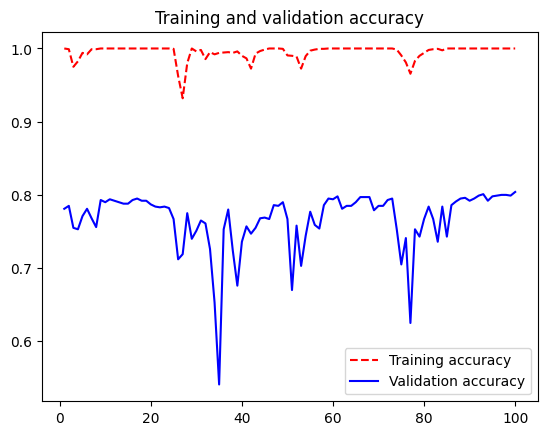

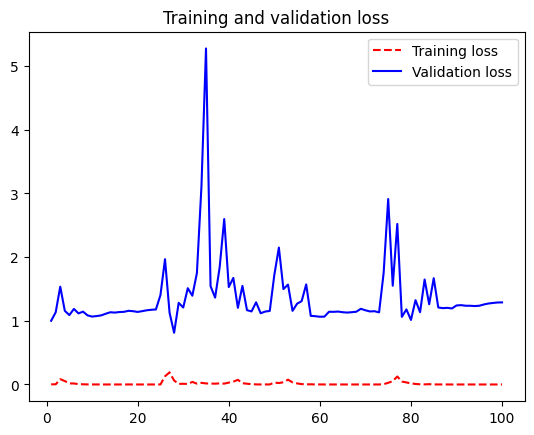

In [ ]:
import matplotlib.pyplot as plt

accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]

loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs = range(1, len(accuracy) + 1)

plt.plot(epochs, accuracy, "r--", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()

plt.plot(epochs, loss, "r--", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()